<a href="https://colab.research.google.com/github/Ebratul/Python/blob/main/Haberman/Haberman's_Survival.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [10]:
df = pd.read_csv('/content/sample_data/haberman.csv',header=None, names=['age', 'year_of_treatment', 'positive_lymph_nodes', 'survival_status_after_5_years'])
df.sample(4)

,age,year_of_treatment,positive_lymph_nodes,survival_status_after_5_years
147,52,63,4,1
216,59,60,0,1
84,45,67,0,1
171,54,59,7,1


In [13]:
df.shape

(306, 4)

In [14]:
df.isnull().sum()

,0
age,0
year_of_treatment,0
positive_lymph_nodes,0
survival_status_after_5_years,0


In [11]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 4 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   age                            306 non-null    int64
 1   year_of_treatment              306 non-null    int64
 2   positive_lymph_nodes           306 non-null    int64
 3   survival_status_after_5_years  306 non-null    int64
dtypes: int64(4)
memory usage: 9.7 KB
None


In [18]:
print(list(df['survival_status_after_5_years'].unique()))

[np.int64(1), np.int64(2)]


In [19]:
df['survival_status_after_5_years'].value_counts()

,count
survival_status_after_5_years,
1,225
2,81


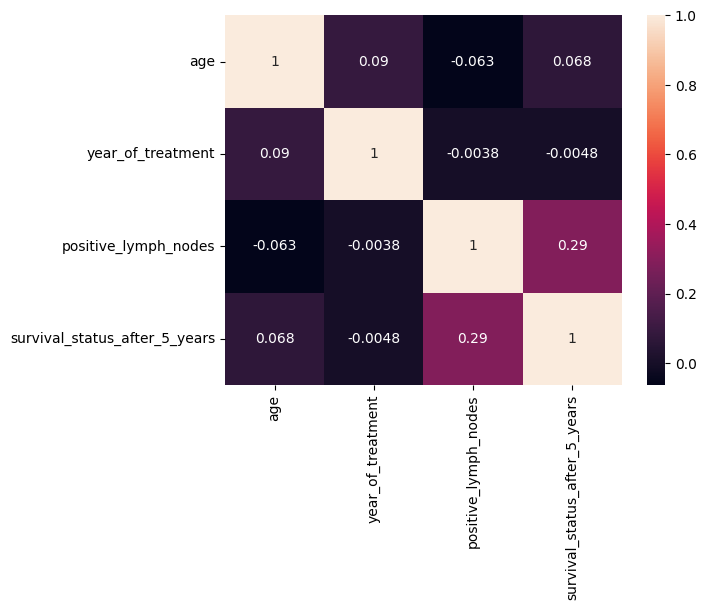

In [15]:
corr = sb.heatmap(df.corr(), annot=True)

In [20]:
df['survival_status_after_5_years'] = df['survival_status_after_5_years'].map({1:'yes', 2:'no'})
df['survival_status_after_5_years'] = df['survival_status_after_5_years'].astype('category')

In [21]:
df.head()

,age,year_of_treatment,positive_lymph_nodes,survival_status_after_5_years
0,30,64,1,yes
1,30,62,3,yes
2,30,65,0,yes
3,31,59,2,yes
4,31,65,4,yes


In [22]:
df.describe()

,age,year_of_treatment,positive_lymph_nodes
count,306.000000,306.000000,306.000000
mean,52.457516,62.852941,4.026144
std,10.803452,3.249405,7.189654
min,30.000000,58.000000,0.000000
25%,44.000000,60.000000,0.000000
50%,52.000000,63.000000,1.000000
75%,60.750000,65.750000,4.000000
max,83.000000,69.000000,52.000000


In [23]:
df['survival_status_after_5_years'].value_counts()

,count
survival_status_after_5_years,
yes,225
no,81


In [24]:
df['survival_status_after_5_years'].value_counts(normalize=True)

,proportion
survival_status_after_5_years,
yes,0.735294
no,0.264706


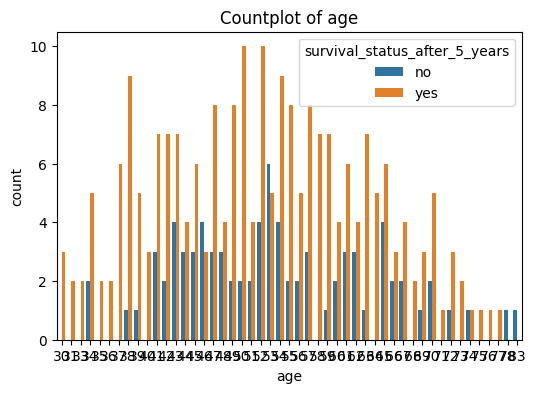

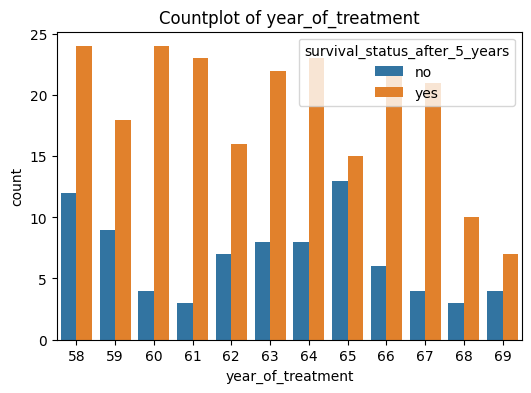

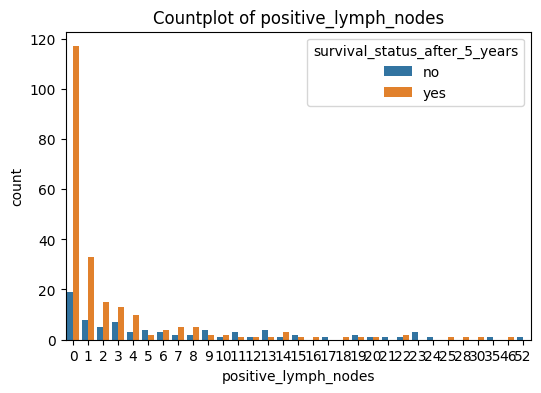

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

for feature in df.columns[:-1]:     # শেষ কলাম target, তাই বাদ
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=feature, hue='survival_status_after_5_years')
    plt.title(f'Countplot of {feature}')
    plt.show()



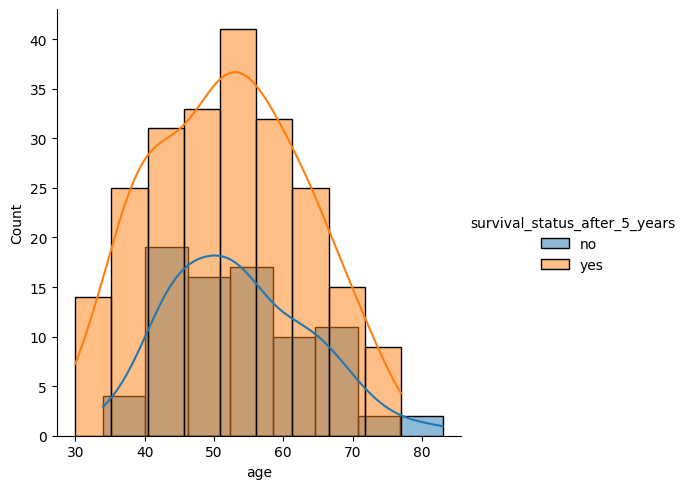

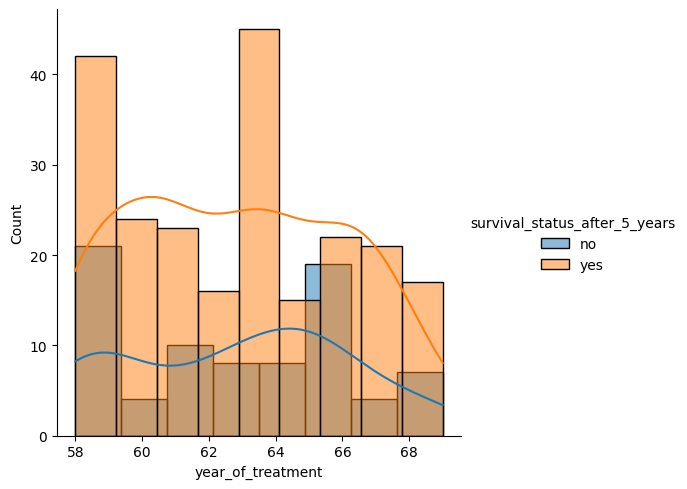

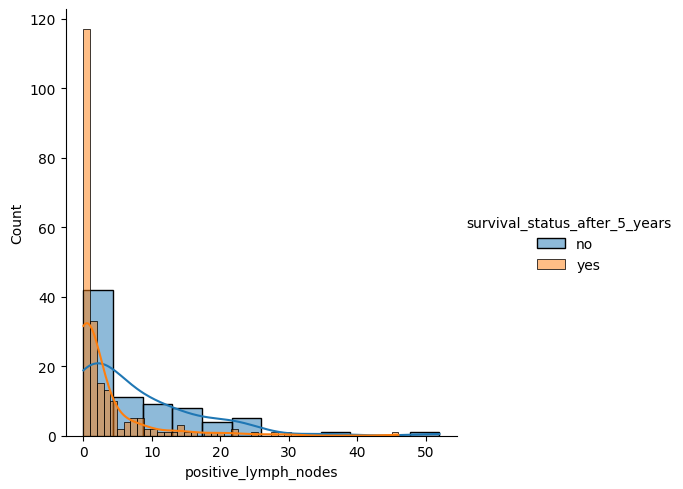

In [28]:
for feature in df.columns[:-1]:    # শেষ কলাম target, বাকি সব feature
    g = sns.FacetGrid(df, hue='survival_status_after_5_years', height=5)
    g.map(sns.histplot, feature, kde=True)
    g.add_legend()
    plt.show()


In [37]:
df['positive_lymph_nodes'].max()

52

In [36]:
np.histogram(list(df['positive_lymph_nodes']))

(array([236,  30,  18,   8,   9,   2,   1,   0,   1,   1]),
 array([ 0. ,  5.2, 10.4, 15.6, 20.8, 26. , 31.2, 36.4, 41.6, 46.8, 52. ]))

********* age *********
Bin Edges: [30.  35.3 40.6 45.9 51.2 56.5 61.8 67.1 72.4 77.7 83. ]
PDF: [0.05228758 0.08823529 0.1503268  0.17320261 0.17973856 0.13398693
 0.13398693 0.05882353 0.02287582 0.00653595]
CDF: [0.05228758 0.14052288 0.29084967 0.46405229 0.64379085 0.77777778
 0.91176471 0.97058824 0.99346405 1.        ]
********* year_of_treatment *********
Bin Edges: [58.  59.1 60.2 61.3 62.4 63.5 64.6 65.7 66.8 67.9 69. ]
PDF: [0.20588235 0.09150327 0.08496732 0.0751634  0.09803922 0.10130719
 0.09150327 0.09150327 0.08169935 0.07843137]
CDF: [0.20588235 0.29738562 0.38235294 0.45751634 0.55555556 0.65686275
 0.74836601 0.83986928 0.92156863 1.        ]
********* positive_lymph_nodes *********
Bin Edges: [ 0.   5.2 10.4 15.6 20.8 26.  31.2 36.4 41.6 46.8 52. ]
PDF: [0.77124183 0.09803922 0.05882353 0.02614379 0.02941176 0.00653595
 0.00326797 0.         0.00326797 0.00326797]
CDF: [0.77124183 0.86928105 0.92810458 0.95424837 0.98366013 0.99019608
 0.99346405 0.99346405 0.996732

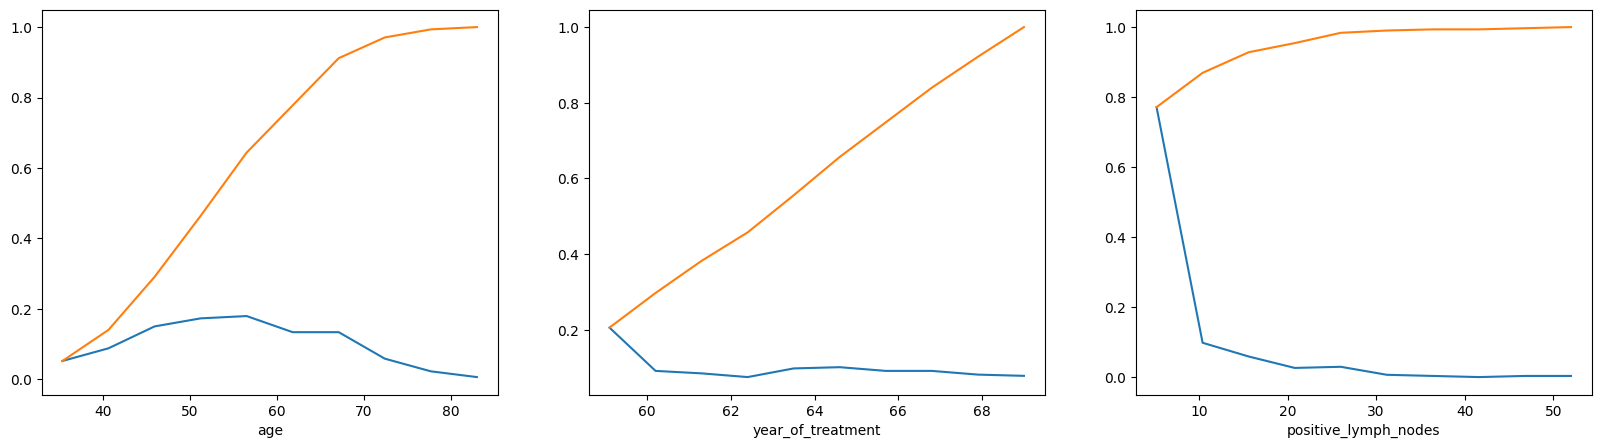

In [42]:
plt.figure(figsize=(20,5))
for idx, feature in enumerate(list(df.columns)[:-1]):
    plt.subplot(1, 3, idx+1)
    print("********* "+feature+" *********")

    counts, bin_edges = np.histogram(df[feature], bins=10, density=True)
    print("Bin Edges: {}".format(bin_edges))

    pdf = counts/sum(counts)
    print("PDF: {}".format(pdf))

    cdf = np.cumsum(pdf)
    print("CDF: {}".format(cdf))

    plt.plot(bin_edges[1:], pdf, bin_edges[1:], cdf)
    plt.xlabel(feature)

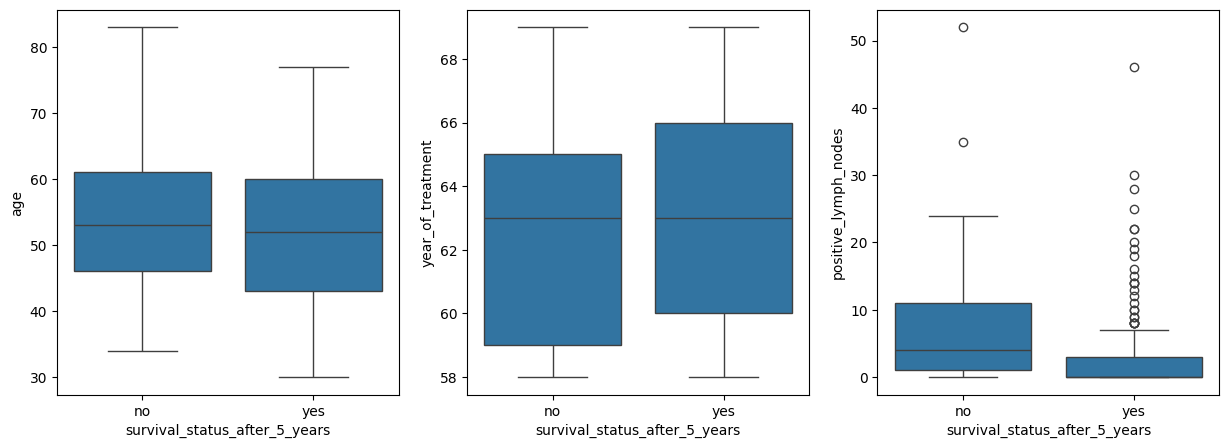

In [43]:
features = df.columns[:-1]   # শেষ কলাম বাদে সব ফিচার

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, feature in enumerate(features):
    sns.boxplot(
        x='survival_status_after_5_years',
        y=feature,
        data=df,
        ax=axes[i]
    )

plt.show()

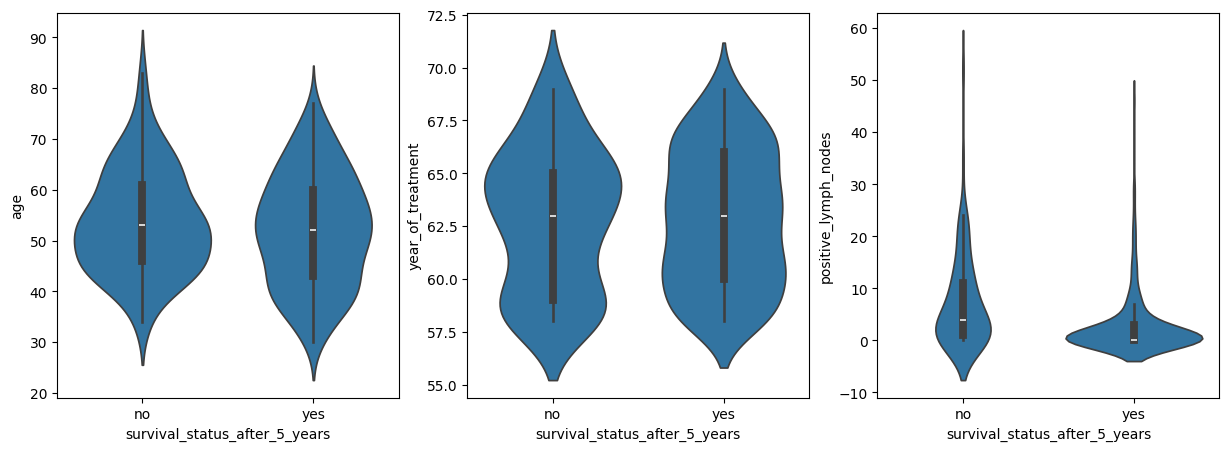

In [44]:
features = df.columns[:-1]   # শেষ কলাম বাদে সব ফিচার

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, feature in enumerate(features):
    sns.violinplot(
        x='survival_status_after_5_years',
        y=feature,
        data=df,
        ax=axes[i]
    )

plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


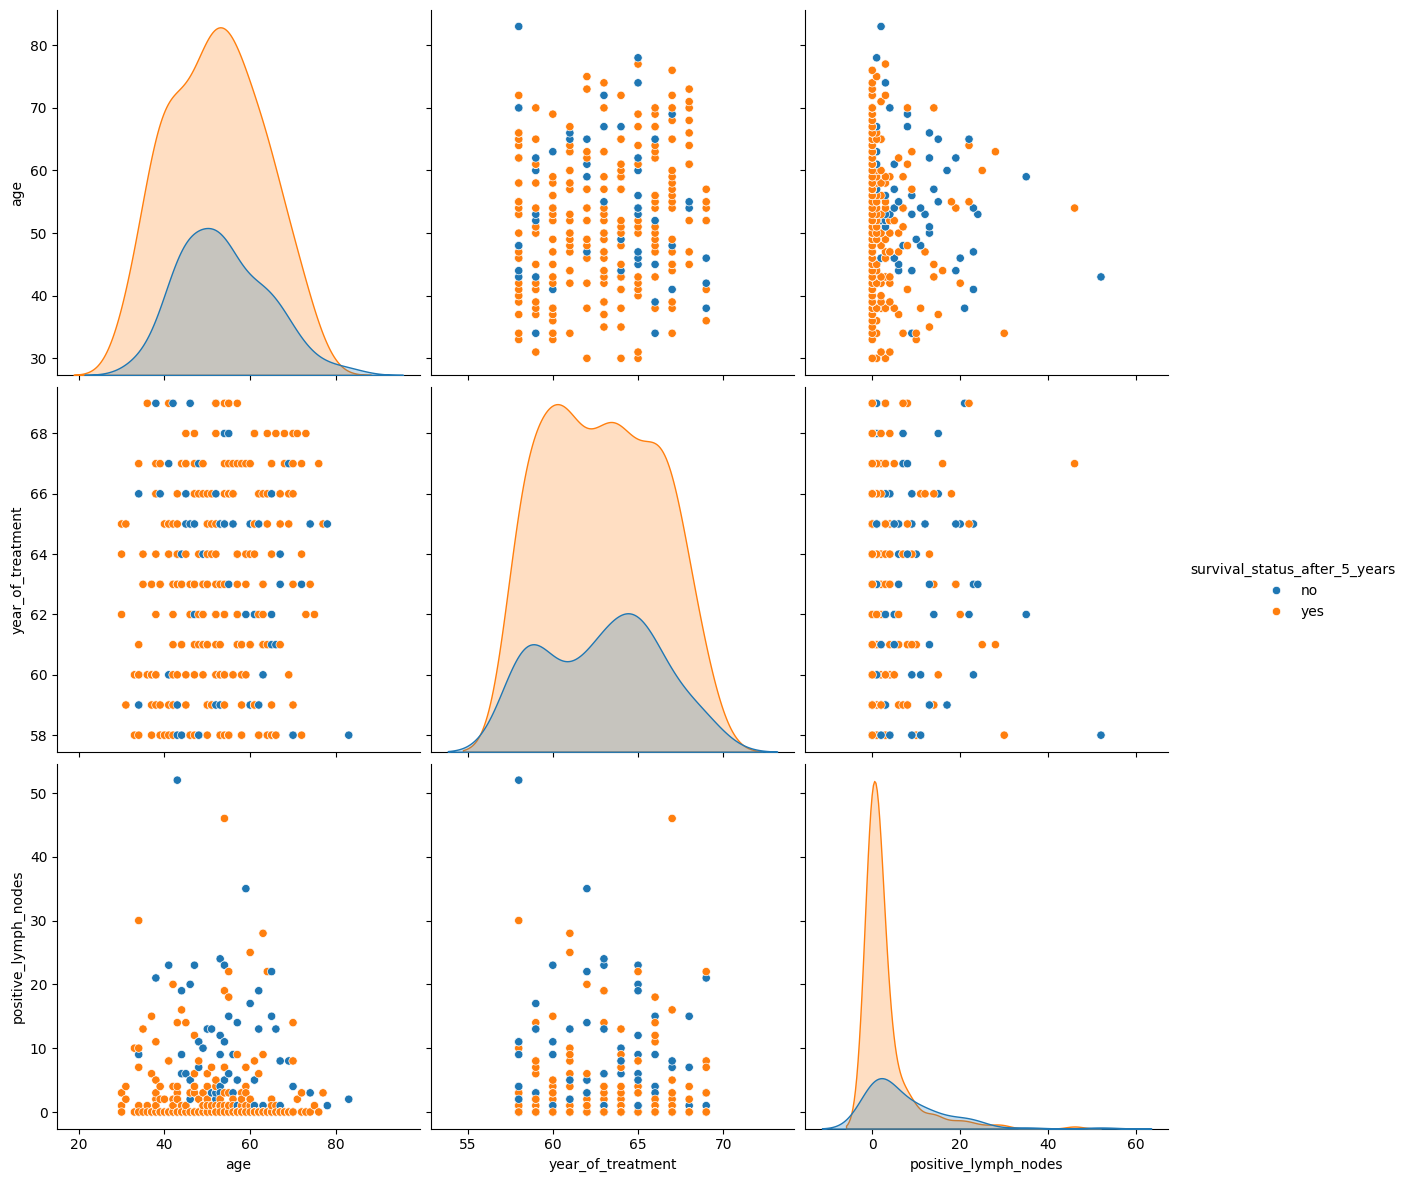

In [45]:
sb.pairplot(df, hue = 'survival_status_after_5_years', size = 4)
plt.show()